# 💨 บทที่ 09 — Doppler Wind: การแก้การพับของความเร็ว (Dealiasing)
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้ gate filter จากบท 03)

**วัตถุประสงค์การเรียนรู้**
- เข้าใจ **Nyquist velocity** และปรากฏการณ์ **การพับของความเร็ว (velocity aliasing/folding)**
- ใช้ `pyart.correct.dealias_region_based` แก้การพับ
- เปรียบเทียบสนามลม **ก่อน/หลัง** การแก้ และระบุบริเวณที่เคยพับ
- อ่านทิศลมเข้า/ออกจากเรดาร์เบื้องต้น

---


## 🧠 หลักการเบื้องต้น

เรดาร์ดอปเปลอร์วัด **ความเร็วตามแนวรัศมี** (radial velocity) จากการเลื่อนเฟสของคลื่นสะท้อน แต่วัดได้เพียงช่วงจำกัด **±Nyquist velocity** ($v_{Ny}$)

เมื่อความเร็วจริง **เกิน** $v_{Ny}$ ค่าจะ **"พับ" (fold/alias)** กลับไปอีกฝั่งของสเกล เช่น ลมออกเร็ว ๆ ที่ควรเป็น +40 m/s แต่ $v_{Ny}=25$ อาจแสดงเป็น −10 m/s ทำให้เห็นขอบเขตสีตัดกันฉับพลัน (สีแดงจัดติดกับสีน้ำเงินจัด) ทั้งที่ลมจริงต่อเนื่อง

**Region-based dealiasing** ของ Py-ART แบ่งข้อมูลเป็นบริเวณ (region) ที่ค่าต่อเนื่องกัน แล้วปรับแต่ละบริเวณด้วยจำนวนเท่าของ $2v_{Ny}$ ให้สนามลมกลับมาต่อเนื่องสมจริง

**การอ่านลม:** ค่า**ลบ = ลมพัดเข้าหาเรดาร์**, ค่า**บวก = ลมพัดออกจากเรดาร์** (เฉพาะองค์ประกอบตามแนวรัศมี)


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 87.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pyart
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson09')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson09


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ อ่านข้อมูล + ดูค่า Nyquist + ความเร็วดิบ (เห็นการพับ)

มองหาบริเวณที่สีตัดกันฉับพลัน (แดงจัด↔น้ำเงินจัด) ในสนามลมที่ต่อเนื่อง = จุดที่เกิดการพับ


Nyquist velocity ของสถานี ≈ ±8.4 m/s


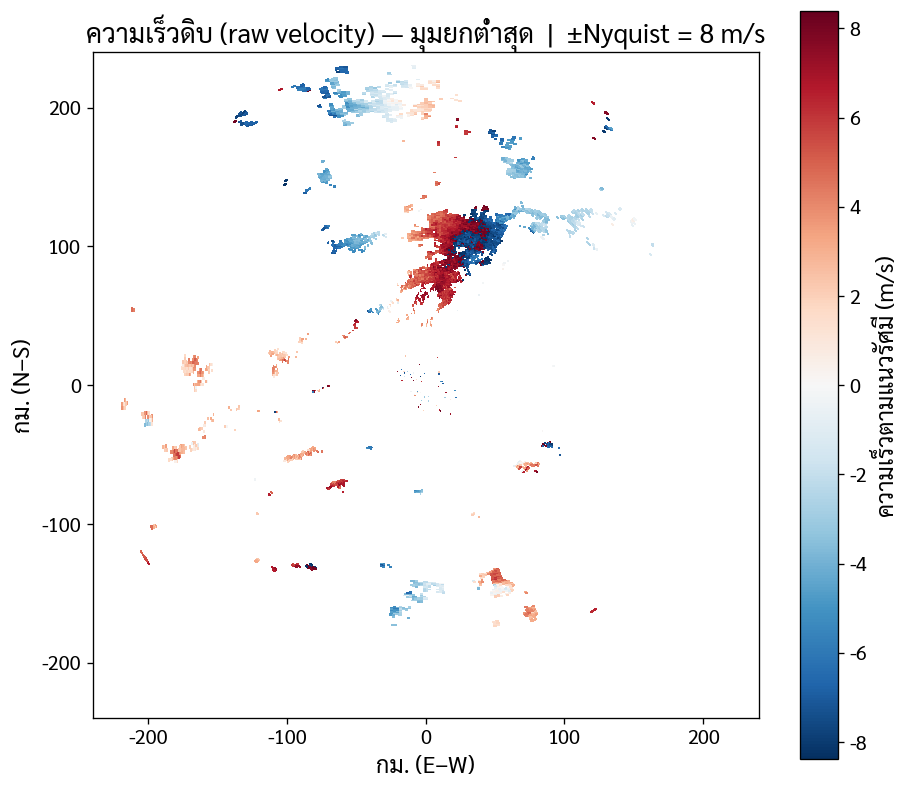

In [ ]:
radar = pyart.io.read(P.RADAR_1000)

try:
    nyq = float(radar.instrument_parameters['nyquist_velocity']['data'][0])
    print(f"Nyquist velocity ของสถานี ≈ ±{nyq:.1f} m/s")
except Exception:
    nyq = 30.0
    print("ไม่พบค่า Nyquist ในไฟล์ — ใช้ค่าโดยประมาณ ±30 m/s")

# กรองคุณภาพก่อน dealias (สำคัญ)
gf = pyart.filters.GateFilter(radar)
gf.exclude_below('cross_correlation_ratio', 0.80)
gf.exclude_masked('velocity')
gf.exclude_invalid('velocity')

fig, ax = plt.subplots(figsize=(8, 7))
disp = pyart.graph.RadarDisplay(radar)
disp.plot('velocity', sweep=0, ax=ax, vmin=-nyq, vmax=nyq, cmap='RdBu_r',
          gatefilter=gf, colorbar_label='ความเร็วตามแนวรัศมี (m/s)',
          title=f'ความเร็วดิบ (raw velocity) — มุมยกต่ำสุด  |  ±Nyquist = {nyq:.0f} m/s')
ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
ax.set_xlabel('กม. (E–W)'); ax.set_ylabel('กม. (N–S)')
plt.tight_layout(); plt.show()

## 2️⃣ แก้การพับด้วย Region-based Dealiasing


In [ ]:
dealias = pyart.correct.dealias_region_based(
    radar, gatefilter=gf, nyquist_vel=nyq, keep_original=False)
radar.add_field('corrected_velocity', dealias, replace_existing=True)

vraw = radar.fields['velocity']['data']
vcor = radar.fields['corrected_velocity']['data']
print(f"ช่วงความเร็ว 'ดิบ'    : {float(np.ma.min(vraw)):+.1f} ถึง {float(np.ma.max(vraw)):+.1f} m/s")
print(f"ช่วงความเร็ว 'แก้แล้ว': {float(np.ma.min(vcor)):+.1f} ถึง {float(np.ma.max(vcor)):+.1f} m/s")
print("→ หลังแก้ ค่าขยายเกิน ±Nyquist ได้ เพราะคลี่การพับออกมาเป็นลมจริง")

ช่วงความเร็ว 'ดิบ'    : -8.3 ถึง +8.3 m/s
ช่วงความเร็ว 'แก้แล้ว': -32.4 ถึง +39.3 m/s
→ หลังแก้ ค่าขยายเกิน ±Nyquist ได้ เพราะคลี่การพับออกมาเป็นลมจริง


## 3️⃣ เปรียบเทียบ ก่อน/หลัง แก้การพับ


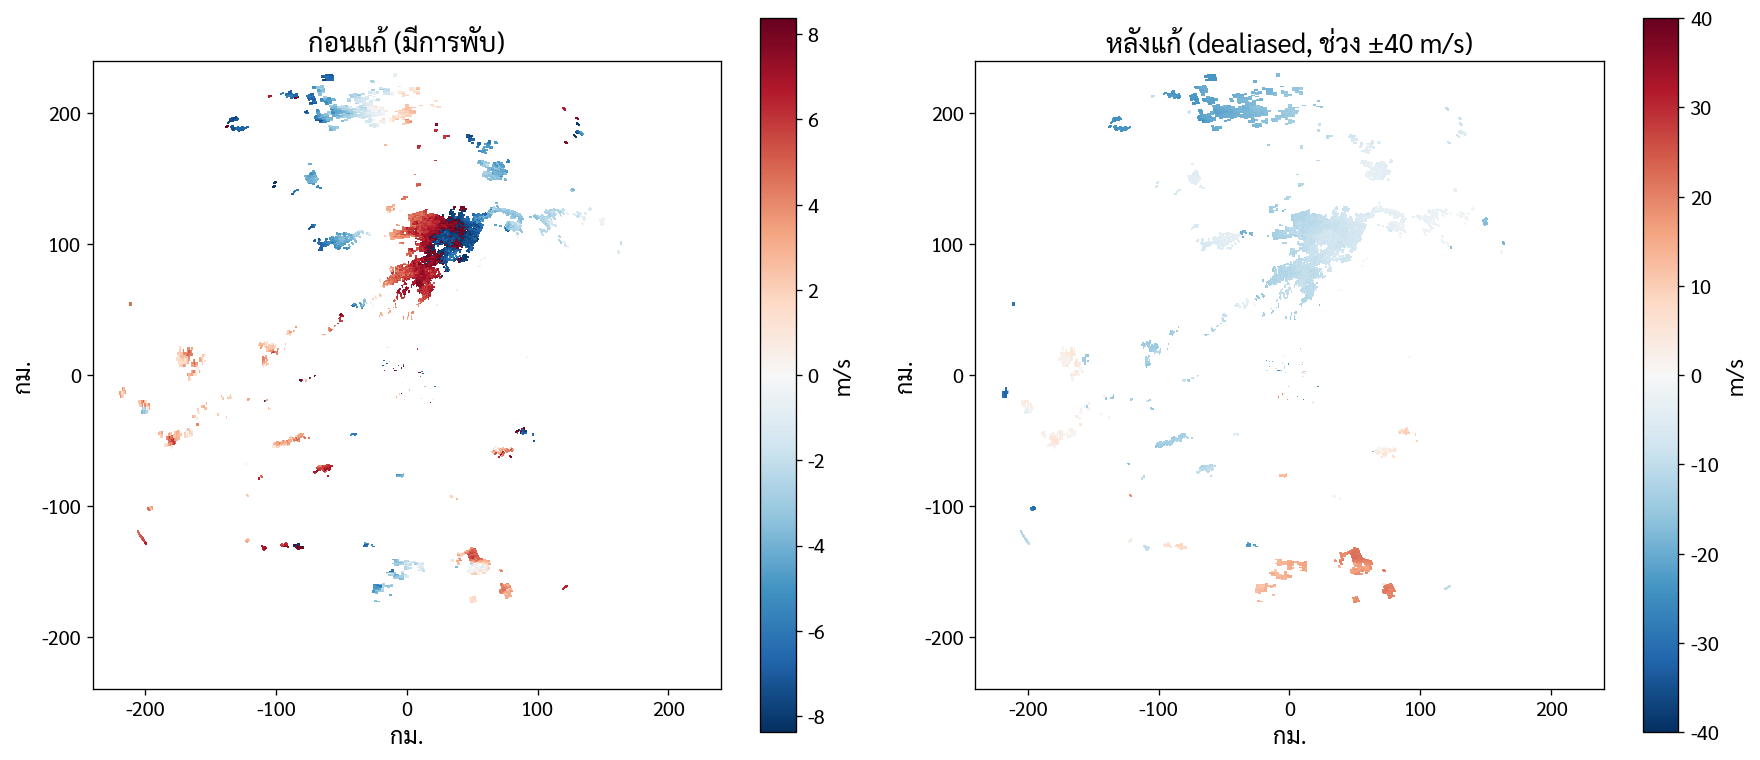

In [ ]:
vlim = float(np.ma.max(np.ma.abs(vcor)))          # ช่วงสำหรับภาพหลังแก้ (กว้างกว่าเดิม)
vlim = np.ceil(vlim / 5) * 5

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
disp = pyart.graph.RadarDisplay(radar)
disp.plot('velocity', sweep=0, ax=axes[0], vmin=-nyq, vmax=nyq, cmap='RdBu_r',
          gatefilter=gf, colorbar_label='m/s', title='ก่อนแก้ (มีการพับ)')
disp.plot('corrected_velocity', sweep=0, ax=axes[1], vmin=-vlim, vmax=vlim, cmap='RdBu_r',
          gatefilter=gf, colorbar_label='m/s', title=f'หลังแก้ (dealiased, ช่วง ±{vlim:.0f} m/s)')
for ax in axes:
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'velocity_before_after_dealias.png'), dpi=300, bbox_inches='tight')
plt.show()

**สังเกต:** หลังแก้ สนามลมต่อเนื่องขึ้น ไม่มีขอบสีตัดกันฉับพลัน และช่วงค่าขยายเกิน ±Nyquist ซึ่งสะท้อนความเร็วลมจริง


## 4️⃣ บริเวณที่ถูกแก้ (เคยพับอยู่ที่ไหน?)

ผลต่าง (แก้แล้ว − ดิบ) จะเป็นทวีคูณของ $2v_{Ny}$ ในบริเวณที่เคยพับ ส่วนบริเวณที่ไม่พับจะเป็น 0


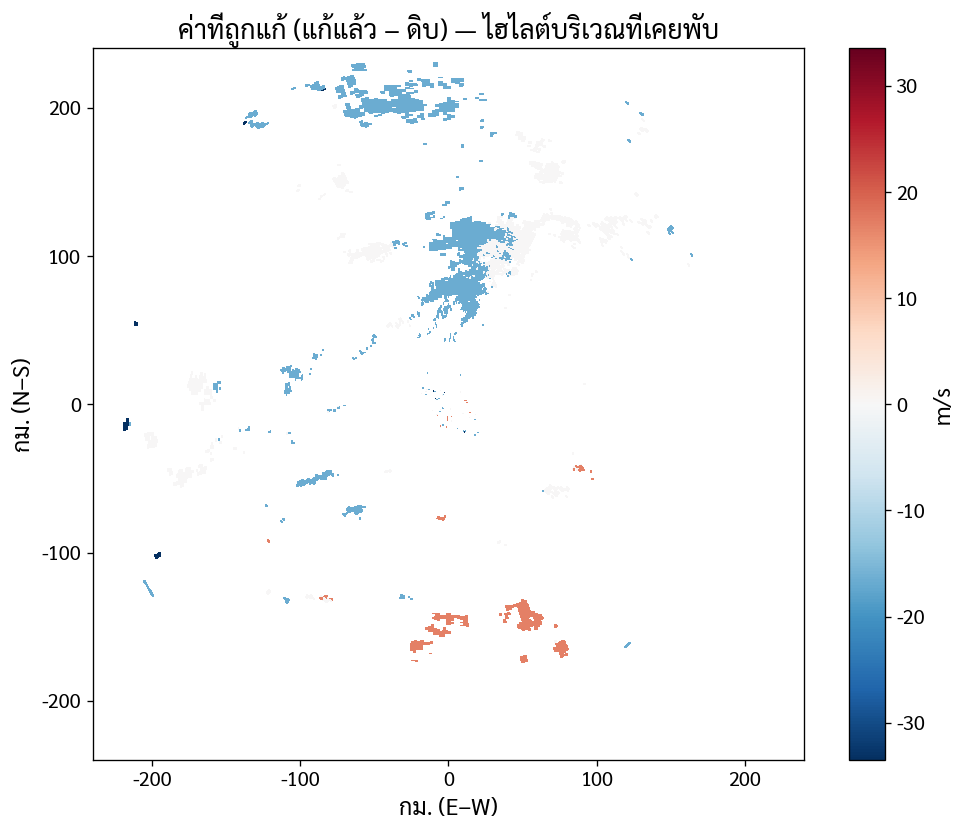

สัดส่วน gate ที่ถูกแก้การพับ ≈ 41.2% ของ gate ที่มีข้อมูลความเร็ว


In [ ]:
diff = vcor - vraw
radar.add_field_like('velocity', 'dealias_correction', diff, replace_existing=True)

dlim = float(np.ma.max(np.ma.abs(diff)))
dlim = max(np.ceil(dlim / (2*nyq)) * 2*nyq, 2*nyq)

fig, ax = plt.subplots(figsize=(8.5, 7))
disp = pyart.graph.RadarDisplay(radar)
disp.plot('dealias_correction', sweep=0, ax=ax, vmin=-dlim, vmax=dlim, cmap='RdBu_r',
          gatefilter=gf, colorbar_label='m/s',
          title='ค่าที่ถูกแก้ (แก้แล้ว − ดิบ) — ไฮไลต์บริเวณที่เคยพับ')
ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
ax.set_xlabel('กม. (E–W)'); ax.set_ylabel('กม. (N–S)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'dealias_correction_regions.png'), dpi=300, bbox_inches='tight')
plt.show()

frac = float((np.ma.abs(diff) > nyq).sum()) / float((~np.ma.getmaskarray(vraw)).sum()) * 100
print(f"สัดส่วน gate ที่ถูกแก้การพับ ≈ {frac:.1f}% ของ gate ที่มีข้อมูลความเร็ว")

## 5️⃣ (ทางเลือก) Velocity Texture — ความหยาบของสนามลม

texture สูงบ่งบอกบริเวณที่ค่าความเร็วปั่นป่วน/สัญญาณรบกวน มักใช้ช่วยแยกฝนจริงออกจาก noise ก่อนวิเคราะห์ลม


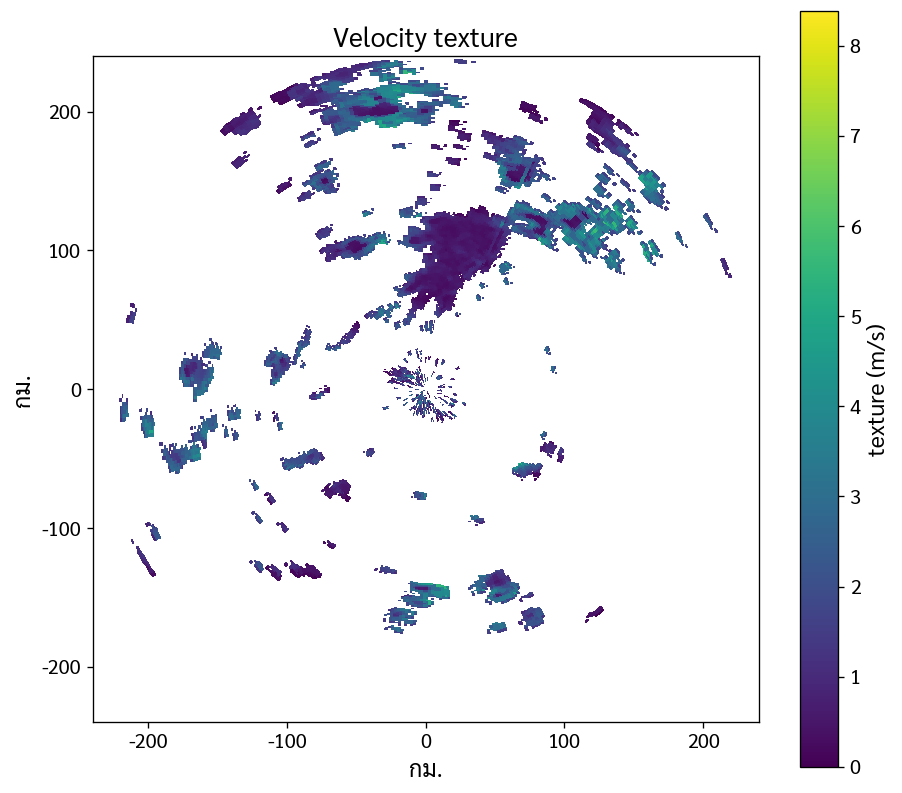

In [ ]:
try:
    tex = pyart.retrieve.calculate_velocity_texture(radar, vel_field='velocity', nyq=nyq)
    radar.add_field('velocity_texture', tex, replace_existing=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = pyart.graph.RadarDisplay(radar)
    disp.plot('velocity_texture', sweep=0, ax=ax, vmin=0, vmax=nyq, cmap='viridis',
              colorbar_label='texture (m/s)', title='Velocity texture')
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')
    plt.tight_layout(); plt.show()
except Exception as e:
    print("ข้าม velocity texture (เวอร์ชัน pyart อาจต่างกัน):", repr(e))

## 📝 แบบฝึกหัด

1. เปลี่ยน `sweep` ไปมุมยกอื่น ๆ แล้วทำ dealias ใหม่ — มุมยกใดมีการพับมากที่สุด เพราะอะไร?
2. ทดลองปรับพารามิเตอร์ `interval_splits` (เช่น 2, 3, 5) ใน `dealias_region_based` แล้วสังเกตความต่อเนื่องของผลลัพธ์
3. จากสนามลมที่แก้แล้ว ลองระบุบริเวณที่ลม "พัดเข้า" และ "พัดออก" จากเรดาร์ และอธิบายรูปแบบการหมุนเวียนที่เห็น


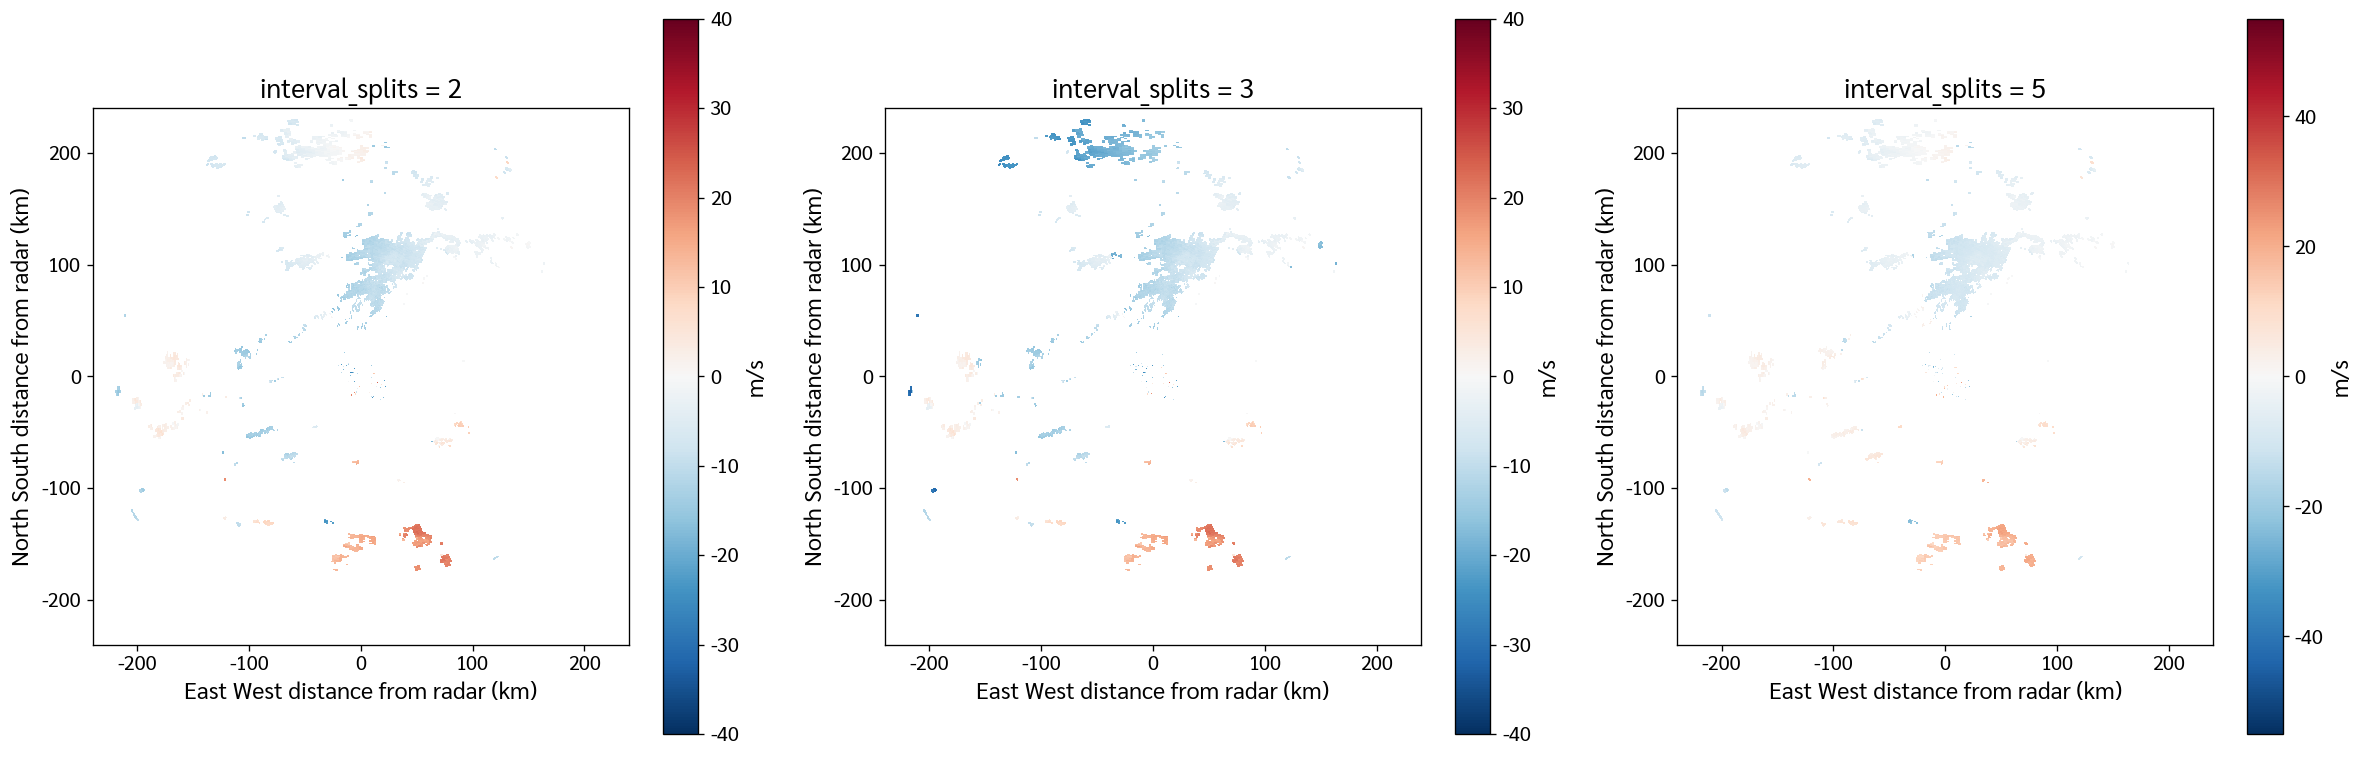

In [ ]:
# แบบฝึกหัดข้อ 2 (โครงเริ่มต้น): เทียบผลของ interval_splits
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
disp = pyart.graph.RadarDisplay(radar)
for ax, k in zip(axes, [2, 3, 5]):
    d = pyart.correct.dealias_region_based(radar, gatefilter=gf, nyquist_vel=nyq,
                                           interval_splits=k, keep_original=False)
    radar.add_field('cv_tmp', d, replace_existing=True)
    vlim_k = np.ceil(float(np.ma.max(np.ma.abs(d['data'])))/5)*5
    disp.plot('cv_tmp', sweep=0, ax=ax, vmin=-vlim_k, vmax=vlim_k, cmap='RdBu_r',
              gatefilter=gf, colorbar_label='m/s', title=f'interval_splits = {k}')
    ax.set_xlim(-240, 240); ax.set_ylim(-240, 240); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 1 และ 3 ต่อ

---
## 🎯 สรุป

- เรดาร์วัดความเร็วได้เพียง ±Nyquist ค่าที่เกินจะ **พับ** ทำให้สนามลมดูไม่ต่อเนื่อง
- `dealias_region_based` คลี่การพับด้วยการปรับแต่ละบริเวณเป็นทวีคูณของ $2v_{Ny}$
- ควร **กรองคุณภาพ (บท 03)** ก่อนทำ dealias เสมอ
- ผลต่าง (แก้แล้ว − ดิบ) ช่วยระบุบริเวณที่เคยพับ

**บทถัดไปที่เกี่ยวข้อง:** การวิเคราะห์ลมขั้นสูง (เช่น VAD/โปรไฟล์ลมแนวดิ่ง) ต่อยอดจากสนามลมที่แก้การพับแล้วนี้
